# 🎼 ADS Homework A01 - Sharif Music Analysis
**Applied Data Science Course 2026**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](PASTE_YOUR_COLAB_URL_HERE)
[![View on GitHub](https://img.shields.io/badge/GitHub-View_Repository-blue?logo=GitHub)](https://github.com/MaximumAsp66915/Applied_Data_Science_Course/blob/main/ADS_A01/notebooks/01_Main_Analysis.ipynb)

Welcome to the comprehensive analysis of the Sharif Music telegram group! This notebook explores the interactions, tracks, artists, and sentiments (reflected by interactions/emojis) of users over the past year. 

### 🎯 Objective Overview

#### 1️⃣ Exploratory Data Analysis (EDA) & Cleaning

#### 2️⃣ 📊 Data Visualization

#### 3️⃣ ⚙️ Feature Engineering

#### 4️⃣ 🕸️ Web Scraping (Bonus Task)

---

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Ignore traditional warnings to keep the notebook readable
import warnings
warnings.filterwarnings('ignore')

# Set visual styles
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


---
#### 1️⃣ Exploratory Data Analysis (EDA) & Cleaning
*   **Comprehensive EDA:** Derive meaningful insights from the interactions, users, and tracks.
*   **Data Cleaning:** Robustly handle missing, invalid, or duplicate values across the dataset.
*   **Preprocessing:** Convert all active features to appropriate numerical representations.
*   **Scaling:** Apply normalization or standardization to set data on comparable scales.
*   **Readability:** Provide clear markdown explanations of all the steps.



## 1. Setup & Data Loading
First, we load the raw datasets extracted from the Telegram channel. We have three main files: `tracks.csv`, `artists.csv`, and `users.csv`.

In [2]:
# Data have to be placed in the data/raw folder
TRACKS_PATH = '../data/raw/tracks.csv'
ARTISTS_PATH = '../data/raw/artists.csv'
USERS_PATH = '../data/raw/users.csv'

try:
    df_tracks = pd.read_csv(TRACKS_PATH)
    df_artists = pd.read_csv(ARTISTS_PATH)
    df_users = pd.read_csv(USERS_PATH)
    
    
    print("✅ Data loaded successfully!\n")
    
    print(f"🎵 Tracks Dataset: {df_tracks.shape[0]} rows, {df_tracks.shape[1]} columns")
    print("Column names:")
    for col in df_tracks.columns:
        print(f"  - {col}")
    print("🔍 Tracks dataset preview:")
    display(df_tracks.head())
    
    print(f"🎤 Artists Dataset: {df_artists.shape[0]} rows, {df_artists.shape[1]} columns")
    print("Column names:")
    for col in df_artists.columns:
        print(f"  - {col}")
    print("🔍 Artists dataset preview:")
    display(df_artists.head())
    
    print(f"👤 Users Dataset: {df_users.shape[0]} rows, {df_users.shape[1]} columns\n")
    print("Column names:")
    for col in df_users.columns:
        print(f"  - {col}")
    print("🔍 Users dataset preview:")
    display(df_users.head())
    
except FileNotFoundError:
    print("⚠️ Raw datasets not found in '../data/raw/'.")

✅ Data loaded successfully!

🎵 Tracks Dataset: 10725 rows, 53 columns
Column names:
  - track_id
  - track_name
  - artist_names
  - artist_count
  - total_likes
  - total_dislikes
  - total_reactions
  - total_comments
  - likes
  - dislikes
  - reactions
  - comments
  - next_track
  - previous_track
  - sender_chat_ids
  - sender_usernames
  - num_senders
  - storage_location
  - inapp_num_likes
  - inapp_num_dislikes
  - inapp_num_reactions
  - inapp_num_comments
  - inapp_num_playlists
  - inapp_likes
  - inapp_dislikes
  - inapp_reactions
  - inapp_comments
  - inapp_playlists
  - album_name
  - released_year
  - released_month
  - released_day
  - in_spotify_playlists
  - in_spotify_charts
  - in_spotify_streams
  - in_spotify_viral
  - in_apple_playlists
  - in_deezer_playlists
  - in_deezer_charts
  - in_shazam_charts
  - bpm
  - key
  - mode
  - genre
  - danceability
  - valence
  - energy
  - acousticness
  - instrumentalness
  - liveness
  - speechiness
  - cover_url
  - s

,track_id,track_name,artist_names,artist_count,total_likes,total_dislikes,total_reactions,total_comments,likes,dislikes,...,genre,danceability,valence,energy,acousticness,instrumentalness,liveness,speechiness,cover_url,streams
0,630156709279300166916839,Everyday Is Christmas,"[""Sia""]",1,0,0,0,0,[],[],...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,799239679632816136087581,Drive You Insane,"[""Daniel Di Angelo""]",1,0,0,0,0,[],[],...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,317966213568013409768079,Shabaye Khat Khati (Prymie.com),"[""Poori""]",1,1,0,1,0,[7081778009],[],...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,480154602683649733755035,Flawless,"[""The Neighbourhood""]",1,7,1,8,0,"[7732627570, 1913497898, 8000666987, 624476088...",[3089727165],...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,552638642383922261022982,I'm Good (Blue),"[""David Guetta"", ""Bebe Rexha""]",2,1,0,1,0,[1350955342],[],...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


🎤 Artists Dataset: 3912 rows, 17 columns
Column names:
  - artist_id
  - artist_name
  - genre
  - albums
  - tracks
  - num_likes
  - num_dislikes
  - num_reactions
  - num_comments
  - likes
  - dislikes
  - reactions
  - comments
  - popularity
  - followers
  - bio
  - social_links
🔍 Artists dataset preview:


,artist_id,artist_name,genre,albums,tracks,num_likes,num_dislikes,num_reactions,num_comments,likes,dislikes,reactions,comments,popularity,followers,bio,social_links
0,509033537247611754713936,Sia,NaN,NaN,NaN,105,1,39,0,"[{""track_id"": ""439415188315743234670815"", ""use...","[{""track_id"": ""568299741497869803403899"", ""use...","[{""track_id"": ""739985379203213241505348"", ""use...",NaN,NaN,NaN,NaN,NaN
1,816153863542257384598981,Daniel Di Angelo,NaN,NaN,NaN,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,483098577617225597603972,Poori,NaN,NaN,NaN,8,0,0,0,"[{""track_id"": ""317966213568013409768079"", ""use...","{""track_id"": ""554301043805960657536081"", ""user...",NaN,NaN,NaN,NaN,NaN,NaN
3,969480178439236779705901,The Neighbourhood,NaN,NaN,NaN,388,34,333,0,"[{""track_id"": ""84977380326341884098638"", ""user...","[{""track_id"": ""183555223223481858028031"", ""use...","[{""track_id"": ""161233143951977610373716"", ""use...",NaN,NaN,NaN,NaN,NaN
4,252932351420662645721765,David Guetta,NaN,NaN,NaN,7,0,4,0,"[{""track_id"": ""552638642383922261022982"", ""use...","{""track_id"": ""742063294398986408964770"", ""user...","[{""track_id"": ""787171182072912539471076"", ""use...",NaN,NaN,NaN,NaN,NaN


👤 Users Dataset: 783 rows, 49 columns

Column names:
  - user_id
  - chat_id
  - username
  - uploaded_tracks
  - liked_tracks
  - disliked_tracks
  - reacted_tracks
  - commented_tracks
  - num_likes
  - num_dislikes
  - num_reactions
  - num_comments
  - likes_received
  - dislikes_received
  - reactions_received
  - comments_received
  - num_likes_received
  - num_dislikes_received
  - num_reactions_received
  - num_comments_received
  - liked_users
  - disliked_users
  - reacted_users
  - commented_users
  - num_liked_users
  - num_disliked_users
  - num_reacted_users
  - num_commented_users
  - users_liked
  - users_disliked
  - users_reacted
  - users_commented
  - num_users_liked
  - num_users_disliked
  - num_users_reacted
  - num_users_commented
  - role
  - level
  - activities
  - flagged
  - first_name
  - last_name
  - language
  - bio
  - birthdate
  - profile_photos
  - phone_number
  - email
  - gender
🔍 Users dataset preview:


,user_id,chat_id,username,uploaded_tracks,liked_tracks,disliked_tracks,reacted_tracks,commented_tracks,num_likes,num_dislikes,...,flagged,first_name,last_name,language,bio,birthdate,profile_photos,phone_number,email,gender
0,1007372695,274199889,amiraliyaz,"[""417274426960227193769044"", ""2399531985100775...","[""374009545182065493971748"", ""9311447697407872...","[""888548233340782812461963"", ""1540370666288252...","[{""track_id"": ""374009545182065493971748"", ""rea...",[],4,2,...,0,Amirali,Yazdiani_F,en,NaN,NaN,[],NaN,NaN,NaN
1,1012117954,764686177,bieyti,"[""707358083028692203708370""]","[""117098130324144545834689"", ""4500853108754460...","[""403111679616960630092190""]","[{""track_id"": ""117098130324144545834689"", ""rea...",[],40,1,...,0,Behina,NaN,en,NaN,NaN,[],NaN,NaN,NaN
2,1015503542,7137193964,NaN,[],"[""164346522850428622921476"", ""5778834253754382...",[],"[{""track_id"": ""164346522850428622921476"", ""rea...",[],8,0,...,0,NaN,NaN,en,NaN,NaN,[],NaN,NaN,NaN
3,1020408191,1105712231,Amin_Behtooei,"[""10419922356096440410066"", ""57110867695017764...","[""67661069417820172013774"", ""76359898201828900...",[],"[{""track_id"": ""67661069417820172013774"", ""reac...",[],276,0,...,0,Amin Behtooei,NaN,en,NaN,NaN,[],NaN,NaN,NaN
4,1027381117,1379319065,DibaHemmati,"[""431042079668215670026281""]",[],[],[],[],0,0,...,0,Diba,Hemmati,en,NaN,NaN,[],NaN,NaN,NaN


### Starting Cleaning Process: Removing Unnecessary Columns

Because the raw database was originally planned for a much larger project, many fields are either entirely empty (null) or fall out of the context of this specific analytical assignment. To streamline our Exploratory Data Analysis, we will clean the datasets by stripping away these irrelevant features.

**Important Note:** The operations below are executed exclusively on the Pandas DataFrames in memory. The core `data/raw/*` `.csv` files remain strictly unmodified, preserving data integrity.

- **Tracks Dataset:** We will drop the `storage_location` column along with any system columns that come after it. Additionally, we will remove unneeded features like `comments`, `next_track`, and `previous_track`.
- **Artists Dataset:** We will remove null or unpopulated social columns (`comments`, `popularity`, `followers`, `bio`, `social_links`, `genre`, `albums`) and the redundant `tracks` array mapping, as we can join the datasets manually.
- **Users Dataset:** We will drop personal or empty metadata (`bio`, `birthdate`, `profile_photos`, `phone_number`, `email`, `gender`), structural roles (`role`, `level`, `activities`, `flagged`), and unused comment-tracking statistics (`commented_tracks`, `num_comments`, `comments_received`, etc.).

In [3]:
if 'df_tracks' in locals() and 'df_artists' in locals() and 'df_users' in locals():
    
    # -----------------------------------------------------
    # 1. Clean Tracks Dataset
    # -----------------------------------------------------
    columns_to_drop_tracks = ['comments', 'next_track', 'previous_track']
    
    # Locate 'storage_location' and collect all columns from it to the end
    if 'storage_location' in df_tracks.columns:
        loc_index = df_tracks.columns.get_loc('storage_location')
        columns_to_drop_tracks.extend(df_tracks.columns[loc_index:])
        
    df_tracks_trimmed = df_tracks.drop(columns=columns_to_drop_tracks, errors='ignore')
    
    # -----------------------------------------------------
    # 2. Clean Artists Dataset
    # -----------------------------------------------------
    columns_to_drop_artists = [
        'comments', 'popularity', 'followers', 'bio', 'social_links', 
        'genre', 'albums', 'tracks'
    ]
    df_artists_trimmed = df_artists.drop(columns=columns_to_drop_artists, errors='ignore')
    
    # -----------------------------------------------------
    # 3. Clean Users Dataset
    # -----------------------------------------------------
    columns_to_drop_users = [
        'commented_tracks', 'num_comments', 'comments_received', 'num_comments_received', 
        'commented_users', 'num_commented_users', 'users_commented', 'num_users_commented', 
        'role', 'level', 'activities', 'flagged', 'bio', 'birthdate', 
        'profile_photos', 'phone_number', 'email', 'gender'
    ]
    df_users_trimmed = df_users.drop(columns=columns_to_drop_users, errors='ignore')
    
    # -----------------------------------------------------
    # Verification & Sample Outputs
    # -----------------------------------------------------
    print("✅ Unnecessary Columns successfully removed!\n")
    
    print(f"🎵 Cleaned Tracks Dataset: {df_tracks_trimmed.shape[0]} rows, {df_tracks_trimmed.shape[1]} columns")
    display(df_tracks_trimmed.head(2))
    
    print(f"\n🎤 Cleaned Artists Dataset: {df_artists_trimmed.shape[0]} rows, {df_artists_trimmed.shape[1]} columns")
    display(df_artists_trimmed.head(2))
    
    print(f"\n👤 Cleaned Users Dataset: {df_users_trimmed.shape[0]} rows, {df_users_trimmed.shape[1]} columns")
    display(df_users_trimmed.head(2))
    
else:
    print("⚠️ DataFrames not populated. Please run the Data Loading cell first.")

✅ Unnecessary Columns successfully removed!

🎵 Cleaned Tracks Dataset: 10725 rows, 14 columns


,track_id,track_name,artist_names,artist_count,total_likes,total_dislikes,total_reactions,total_comments,likes,dislikes,reactions,sender_chat_ids,sender_usernames,num_senders
0,630156709279300166916839,Everyday Is Christmas,"[""Sia""]",1,0,0,0,0,[],[],[],[0],[null],1
1,799239679632816136087581,Drive You Insane,"[""Daniel Di Angelo""]",1,0,0,0,0,[],[],[],[0],[null],1



🎤 Cleaned Artists Dataset: 3912 rows, 9 columns


,artist_id,artist_name,num_likes,num_dislikes,num_reactions,num_comments,likes,dislikes,reactions
0,509033537247611754713936,Sia,105,1,39,0,"[{""track_id"": ""439415188315743234670815"", ""use...","[{""track_id"": ""568299741497869803403899"", ""use...","[{""track_id"": ""739985379203213241505348"", ""use..."
1,816153863542257384598981,Daniel Di Angelo,0,0,0,0,NaN,NaN,NaN



👤 Cleaned Users Dataset: 783 rows, 31 columns


,user_id,chat_id,username,uploaded_tracks,liked_tracks,disliked_tracks,reacted_tracks,num_likes,num_dislikes,num_reactions,...,num_reacted_users,users_liked,users_disliked,users_reacted,num_users_liked,num_users_disliked,num_users_reacted,first_name,last_name,language
0,1007372695,274199889,amiraliyaz,"[""417274426960227193769044"", ""2399531985100775...","[""374009545182065493971748"", ""9311447697407872...","[""888548233340782812461963"", ""1540370666288252...","[{""track_id"": ""374009545182065493971748"", ""rea...",4,2,6,...,5,"[6649352285, 8667816286, 9364416709, 477214934...",[6582252810],"[{""user_id"": 6649352285, ""reaction"": ""🔥""}, {""u...",37,1,55,Amirali,Yazdiani_F,en
1,1012117954,764686177,bieyti,"[""707358083028692203708370""]","[""117098130324144545834689"", ""4500853108754460...","[""403111679616960630092190""]","[{""track_id"": ""117098130324144545834689"", ""rea...",40,1,41,...,33,"[2094817151, 2804041751, 2377298811, 813769000...",[],"[{""user_id"": 2094817151, ""reaction"": ""❤""}, {""u...",11,0,11,Behina,NaN,en


### ID Simplification Strategy (Refactoring large identifiers)

Currently, the primary keys (`track_id`, `artist_id`, and `user_id`) natively exported from Telegram are unwieldy sequences (e.g., massive numerical identifiers or UUIDs) making statistical groupings less intuitive to debug natively, This was due to the next upcoming project and for security issues there that I desided to go with 16digit-long UUIDs.

To convert our data architecture to a localized layout designed solely for this EDA class:
1. We will **normalize all core IDs** so they increment simply from 1 upwards.
2. If `user_id 9245100023` becomes `1` in the User's Dataset, we must predictably map any track explicitly connected to `uploaded_by_user_id = 9245100023` cleanly over to `1` as well.
3. This exact sequential mapping rule applies symmetrically directly to the Artist tables.

_To maintain architecture maturity locally, this complex dataframe traversal operation has been offloaded into one of our modular Python scripts built inside `src/preprocessing/id_simplifier.py`. We'll just call the functions directly from there!_

In [4]:
import sys

# Explicitly insert the root Project path so Python finds the src folder.
sys.path.append("..") 

# Import our custom simplifier module smoothly and functionally
from src.preprocessing.id_simplifier import simplify_all_ids

if 'df_tracks_trimmed' in locals() and 'df_artists_trimmed' in locals() and 'df_users_trimmed' in locals():

    # Re-map and transform all the linked IDs iteratively via the imported class
    df_tracks_simplified, df_artists_simplified, df_users_simplified = simplify_all_ids(
        df_tracks=df_tracks_trimmed, 
        df_artists=df_artists_trimmed, 
        df_users=df_users_trimmed
    )
    
    print("✅ IDs effectively mapped recursively from 1 incrementally!")
    print("Take a look at the newly sanitized and fully refactored dataset IDs:\n")
    
    display(df_tracks_simplified.head(5))
    display(df_artists_simplified.head(5))
    display(df_users_simplified.head(5))
else:
    print("⚠️ Cleaned DataFrames drop phase not run. Run the above cells linearly first.")

✅ IDs effectively mapped recursively from 1 incrementally!
Take a look at the newly sanitized and fully refactored dataset IDs:



,track_id,track_name,artist_names,artist_count,total_likes,total_dislikes,total_reactions,total_comments,likes,dislikes,reactions,sender_chat_ids,sender_usernames,num_senders
0,1,Everyday Is Christmas,"[""Sia""]",1,0,0,0,0,[],[],[],[0],[null],1
1,2,Drive You Insane,"[""Daniel Di Angelo""]",1,0,0,0,0,[],[],[],[0],[null],1
2,3,Shabaye Khat Khati (Prymie.com),"[""Poori""]",1,1,0,1,0,[519],[],"[{""user_id"": 519, ""reaction"": ""🔥""}]",[0],[null],1
3,4,Flawless,"[""The Neighbourhood""]",1,7,1,8,0,"[569, 76, 593, 442, 623, 230, 594]",[161],"[{""user_id"": 569, ""reaction"": ""❤""}, {""user_id""...","[0, 8169944569]","[null, ""ReggieGrumpyBlack""]",2
4,5,I'm Good (Blue),"[""David Guetta"", ""Bebe Rexha""]",2,1,0,1,0,[35],[],"[{""user_id"": 35, ""reaction"": ""❤""}]",[0],[null],1


,artist_id,artist_name,num_likes,num_dislikes,num_reactions,num_comments,likes,dislikes,reactions
0,1,Sia,105,1,39,0,"[{""track_id"": 9, ""user_id"": 248}, {""track_id"":...","[{""track_id"": 6165, ""user_id"": 424, ""reaction""...","[{""track_id"": 6523, ""user_id"": 111, ""reaction""..."
1,2,Daniel Di Angelo,0,0,0,0,NaN,NaN,NaN
2,3,Poori,8,0,0,0,"[{""track_id"": 3, ""user_id"": 519}, {""track_id"":...","{""track_id"": 4269, ""user_id"": 311, ""reaction"":...",NaN
3,4,The Neighbourhood,388,34,333,0,"[{""track_id"": 892, ""user_id"": 363}, {""track_id...","[{""track_id"": 6691, ""user_id"": 161}, {""track_i...","[{""track_id"": 6468, ""user_id"": 329, ""reaction""..."
4,5,David Guetta,7,0,4,0,"[{""track_id"": 5, ""user_id"": 35}, {""track_id"": ...","{""track_id"": 2925, ""user_id"": 490, ""reaction"":...","[{""track_id"": 8738, ""user_id"": 707, ""reaction""..."


,user_id,chat_id,username,uploaded_tracks,liked_tracks,disliked_tracks,reacted_tracks,num_likes,num_dislikes,num_reactions,...,num_reacted_users,users_liked,users_disliked,users_reacted,num_users_liked,num_users_disliked,num_users_reacted,first_name,last_name,language
0,1,274199889,amiraliyaz,"[705, 3088, 67, 3376, 2551, 4125, 4126, 4171, ...","[1039, 5999, 6138, 3221]","[6717, 6749]","[{""track_id"": 1039, ""reaction"": ""❤""}, {""track_...",4,2,6,...,5,"[486, 655, 725, 303, 122, 311, 346, 40, 568, 6...",[477],"[{""user_id"": 486, ""reaction"": ""🔥""}, {""user_id""...",37,1,55,Amirali,Yazdiani_F,en
1,2,764686177,bieyti,[9900],"[8723, 8760, 9491, 9515, 9190, 9541, 498, 9546...",[10293],"[{""track_id"": 8723, ""reaction"": ""❤‍🔥""}, {""trac...",40,1,41,...,33,"[94, 141, 112, 609, 608, 720, 309, 648, 220, 6...",[],"[{""user_id"": 94, ""reaction"": ""❤""}, {""user_id"":...",11,0,11,Behina,NaN,en
2,3,7137193964,NaN,[],"[1407, 2234, 2472, 2550, 2652, 2686, 820, 3133]",[],"[{""track_id"": 1407, ""reaction"": ""❤‍🔥""}, {""trac...",8,0,8,...,7,[],[],[],0,0,0,NaN,NaN,en
3,4,1105712231,Amin_Behtooei,"[1950, 2016, 2061, 2132, 2204, 2272, 922, 2432...","[857, 1717, 1977, 2025, 2030, 2049, 2056, 2058...",[],"[{""track_id"": 857, ""reaction"": ""❤""}, {""track_i...",276,0,279,...,105,"[775, 43, 548, 41, 7, 29, 567, 311, 25, 40, 25...",[160],"[{""user_id"": 775, ""reaction"": ""❤‍🔥""}, {""user_i...",92,1,170,Amin Behtooei,NaN,en
4,5,1379319065,DibaHemmati,[4396],[],[],[],0,0,0,...,0,[371],[],"[{""user_id"": 371, ""reaction"": ""👍""}]",1,0,1,Diba,Hemmati,en


*You see how much cleaner the data has got but its not ready yet and we have more steps to take!*

### 💾 Saving Processed Data

Now that our datasets are cleaned and the IDs have been simplified, we will save these intermediate results into the `data/processed/` directory. This ensures we have a clean, easily accessible starting point for our upcoming Exploratory Data Analysis (EDA) and visualization steps without needing to re-run the entire cleaning pipeline.

In [5]:
import os

processed_dir = "../data/processed"
os.makedirs(processed_dir, exist_ok=True)

# Save the simplified datasets
# Intermediate saves are commented out to keep the datasets in memory
df_tracks_simplified.to_csv(f"{processed_dir}/tracks_simplified.csv", index=False)
df_artists_simplified.to_csv(f"{processed_dir}/artists_simplified.csv", index=False)
df_users_simplified.to_csv(f"{processed_dir}/users_simplified.csv", index=False)

print("✅ Preprocessing step complete. Intermediate datasets are stored in memory!")

✅ Preprocessing step complete. Intermediate datasets are stored in memory!


---
#### 🥞 Flattening Simple Lists & Handling Null Artifacts
Here we convert simple array-like string properties like `["David Guetta", "Bebe Rexha"]` into comma-separated strings (`"David Guetta, Bebe Rexha"`) so that machine learning and text processing models can consume them efficiently.
Simultaneously, we transform dummy literal representations like `"[null]"` or `"null"` into proper native `NaN` representations to ensure our datasets remain mathematically robust for visualization and feature engineering.

In [6]:
import sys
import importlib
sys.path.append(r"../src/preprocessing")
import flattener
importlib.reload(flattener)
from flattener import flatten_and_clean

# Apply flattening and clean artifacts
df_tracks_simplified2, df_artists_simplified2, df_users_simplified2 = flatten_and_clean(
    df_tracks_simplified, df_artists_simplified, df_users_simplified
)

print("✅ Lists flattened and null artifacts converted to NaN!")

# Display preview of ALL datasets flattened targets
print("🎵 Tracks Flattened Preview:")
display(df_tracks_simplified2.head(5))

print("\n🎤 Artists Flattened Preview:")
display(df_artists_simplified2.head(5))

print("\n👤 Users Flattened Preview:")
display(df_users_simplified2.head(5))

✅ Lists flattened and null artifacts converted to NaN!
🎵 Tracks Flattened Preview:


,track_id,track_name,artist_names,artist_count,total_likes,total_dislikes,total_reactions,total_comments,likes,dislikes,reactions,sender_chat_ids,sender_usernames,num_senders
0,1,Everyday Is Christmas,Sia,1,0,0,0,0,NaN,NaN,NaN,0,NaN,1
1,2,Drive You Insane,Daniel Di Angelo,1,0,0,0,0,NaN,NaN,NaN,0,NaN,1
2,3,Shabaye Khat Khati (Prymie.com),Poori,1,1,0,1,0,519,NaN,519:🔥,0,NaN,1
3,4,Flawless,The Neighbourhood,1,7,1,8,0,"569, 76, 593, 442, 623, 230, 594",161,"569:❤, 76:❤, 593:❤, 442:❤, 623:❤‍🔥, 161:👎, 230...","0, 8169944569",ReggieGrumpyBlack,2
4,5,I'm Good (Blue),"David Guetta, Bebe Rexha",2,1,0,1,0,35,NaN,35:❤,0,NaN,1



🎤 Artists Flattened Preview:


,artist_id,artist_name,num_likes,num_dislikes,num_reactions,num_comments,likes,dislikes,reactions
0,1,Sia,105,1,39,0,"248, 65, 424, 734, 252, 311, 447, 490, 86, 255...","424, 477","111:❤, 119:❤, 477:❤, 160:❤, 608:❤, 695:❤, 111:..."
1,2,Daniel Di Angelo,0,0,0,0,NaN,NaN,NaN
2,3,Poori,8,0,0,0,"519, 40, 458, 56, 346, 70, 228, 311",311,NaN
3,4,The Neighbourhood,388,34,333,0,"363, 39, 519, 266, 783, 320, 327, 252, 661, 73...","161, 161, 161, 161, 161, 161, 161, 161, 161, 1...","329:❤, 707:👍, 214:❤, 442:❤, 598:❤, 593:❤, 772:..."
4,5,David Guetta,7,0,4,0,"35, 196, 490, 707, 324, 594, 724",490,"707:🎉, 324:⚡, 594:⚡, 724:⚡"



👤 Users Flattened Preview:


,user_id,chat_id,username,uploaded_tracks,liked_tracks,disliked_tracks,reacted_tracks,num_likes,num_dislikes,num_reactions,...,num_reacted_users,users_liked,users_disliked,users_reacted,num_users_liked,num_users_disliked,num_users_reacted,first_name,last_name,language
0,1,274199889,amiraliyaz,"705, 3088, 67, 3376, 2551, 4125, 4126, 4171, 5...","1039, 5999, 6138, 3221","6717, 6749","1039:❤, 5999:❤, 6138:❤, 3221:💔, 6717:👎, 6749:👎",4,2,6,...,5,"486, 655, 725, 303, 122, 311, 346, 40, 568, 64...",477,"486:🔥, 655:🔥, 725:😁, 303:😁, 655:⚡, 122:⚡, 311:...",37,1,55,Amirali,Yazdiani_F,en
1,2,764686177,bieyti,9900,"8723, 8760, 9491, 9515, 9190, 9541, 498, 9546,...",10293,"8723:❤‍🔥, 8760:❤‍🔥, 9491:💘, 9515:❤‍🔥, 9190:❤‍🔥...",40,1,41,...,33,"94, 141, 112, 609, 608, 720, 309, 648, 220, 61...",NaN,"94:❤, 141:❤, 112:❤, 609:❤, 608:❤, 720:❤, 309:❤...",11,0,11,Behina,NaN,en
2,3,7137193964,NaN,NaN,"1407, 2234, 2472, 2550, 2652, 2686, 820, 3133",NaN,"1407:❤‍🔥, 2234:❤, 2472:❤‍🔥, 2550:❤‍🔥, 2652:🍾, ...",8,0,8,...,7,NaN,NaN,NaN,0,0,0,NaN,NaN,en
3,4,1105712231,Amin_Behtooei,"1950, 2016, 2061, 2132, 2204, 2272, 922, 2432,...","857, 1717, 1977, 2025, 2030, 2049, 2056, 2058,...",NaN,"857:❤, 1717:🔥, 1977:❤, 2025:❤‍🔥, 2030:❤‍🔥, 204...",276,0,279,...,105,"775, 43, 548, 41, 7, 29, 567, 311, 25, 40, 255...",160,"775:❤‍🔥, 43:❤‍🔥, 548:❤‍🔥, 41:❤‍🔥, 7:❤‍🔥, 29:❤‍...",92,1,170,Amin Behtooei,NaN,en
4,5,1379319065,DibaHemmati,4396,NaN,NaN,NaN,0,0,0,...,0,371,NaN,371:👍,1,0,1,Diba,Hemmati,en


---
#### 📝 Text Normalization
Consistent text formatting ensures the robustness of future models parsing strings (like `CountVectorizer` or `TF-IDF`), and limits unexpected behaviors caused by invisible trailing whitespaces, random upper/lowercase permutations, and weird symbols.
In this step, we will convert all relevant categorical string columns to **lowercase** and strip any leading or trailing **whitespaces**.

Also we would not touch the texts inside the users_dataset because they have already been normalized by telegram system and they are uniqe and normalized enough also Normalizing them more like lowercasing all the letters for the username and first_name and last_name are not that suitable for the users as this data might be shown to them later on!

In [7]:
import text_normalizer
importlib.reload(text_normalizer)
from text_normalizer import normalize_texts

# Apply text normalization
df_tracks_normalized, df_artists_normalized = normalize_texts(
    df_tracks_simplified2, df_artists_simplified2
)

print("✅ Text features consistently normalized (lowercased and stripped)!")

# Preview the completely final prepared Tracks DataFrame
display(df_tracks_normalized[['track_name', 'artist_names', 'sender_usernames']].head(10))
display(df_artists_normalized[['artist_name']].head(10))

✅ Text features consistently normalized (lowercased and stripped)!


,track_name,artist_names,sender_usernames
0,everyday is christmas,sia,NaN
1,drive you insane,daniel di angelo,NaN
2,shabaye khat khati (prymie.com),poori,NaN
3,flawless,the neighbourhood,reggiegrumpyblack
4,i'm good (blue),"david guetta, bebe rexha",NaN
5,i like you (a happier song) (feat. doja cat),post malone,NaN
6,coffee cups and cigarettes‌,tomo • @resteici,NaN
7,boombastic,shaggy,NaN
8,snowman,sia,"javadtwf, mah13541347"
9,we fell in love in october,girl in red,"khodezekavat, feft_1107"


,artist_name
0,sia
1,daniel di angelo
2,poori
3,the neighbourhood
4,david guetta
5,bebe rexha
6,post malone
7,tomo • @resteici
8,shaggy
9,girl in red


---
#### 🔎 Pattern Extraction & Advanced Name Cleaning
Many entries in `track_name` and `artist_names` contain unsuitable or mixed formatting styles (like `•`, brackets, emojis, or unwanted promotional URLs). While `sender_usernames` is fine as-is (they rely on exact telegram database registrations), track and artist names need specific text mining. 

In this step, instead of looping manually, we use `pandas.Series.str` vectorization to:
1. Reveal strange patterns (bullet points, parenthesis metadata like `(Prymie.com)`).
2. Clean and standardize the strings directly within active memory.

In [8]:
import re

def extract_and_clean_names(df_tracks, df_artists):
    """
    Uses Pandas vectorized string operations to find and remove unwanted text
    patterns or characters from track and artist names.
    """
    t_df = df_tracks.copy()
    a_df = df_artists.copy()
    
    # Regex definitions for URLs and illegal characters
    link_pat = r'(?i)(?:https?://)?(?:www\.)?[a-zA-Z0-9-]+\.(?:com|ir|org|net|info|me)[^\s]*'
    ill_char_pat = r'•|►|-|_|©|™|~|♫| |🆔|=|🎧'
    
    # 1. View strange patterns (e.g. matching anything in parenthesis, brackets or bullet points)
    print("--- 🧐 Sample dirty patterns in Tracks (e.g., promotional sites) ---")
    dirty_tracks = t_df[t_df['track_name'].str.contains(r'(?i)\(\s*(?!(?:feat|ft|remaster|remix|live|remastered|blue)\b).*?\)|\[.*?\]|•', na=False, regex=True)]
    display(dirty_tracks[['track_name', 'artist_names']])
    
    # 2. Tracks Cleaning
    # Convert [feat/ft ...] to (feat/ft ...)
    t_df['track_name'] = t_df['track_name'].str.replace(r'(?i)\[(\s*(?:feat|ft|remaster|remix|live|remastered|blue)\b.*?)\]', r'(\1)', regex=True)
    # Remove text in parentheses/brackets but preserve (feat/ft ...)
    t_df['track_name'] = t_df['track_name'].str.replace(r'(?i)\(\s*(?!(?:feat|ft|remaster|remix|live|remastered|blue)\b).*?\)|\[.*?\]', '', regex=True)
    # Remove URLs/Links
    t_df['track_name'] = t_df['track_name'].str.replace(link_pat, ' ', regex=True)
    # Remove weird characters
    t_df['track_name'] = t_df['track_name'].str.replace(ill_char_pat, ' ', regex=True)
    # Strip double spaces created from the removal
    t_df['track_name'] = t_df['track_name'].str.replace(r'\s+', ' ', regex=True).str.strip()
    # Replace empty tracks that got completely stripped with 'unknown'
    t_df.loc[t_df['track_name'] == '', 'track_name'] = 'unknown'

    # 3. Artists Cleaning
    # Artist names sometimes have promotional garbage like @username or •
    print("\n--- 🧐 Sample dirty patterns in Artists (e.g., social tags) ---")
    dirty_artists = a_df[a_df['artist_name'].str.contains(r'[@•\(\)]', na=False, regex=True)]
    display(dirty_artists[['artist_name']])
    
    # Clean artists: remove anything after @ (often an instagram tag) and URLs
    a_df['artist_name'] = a_df['artist_name'].str.replace(r'@\S+', '', regex=True)
    a_df['artist_name'] = a_df['artist_name'].str.replace(link_pat, ' ', regex=True)
    a_df['artist_name'] = a_df['artist_name'].str.replace(r'\(|\)|\[|\]', '', regex=True)
    a_df['artist_name'] = a_df['artist_name'].str.replace(ill_char_pat, ' ', regex=True)
    a_df['artist_name'] = a_df['artist_name'].str.replace(r'\s+', ' ', regex=True).str.strip()
    # Replace totally vanished artists with 'unknown' to keep counts valid
    a_df.loc[a_df['artist_name'] == '', 'artist_name'] = 'unknown'
    
    # Update relational columns as well to keep them perfectly synced
    if 'artist_names' in t_df.columns:
        t_df['artist_names'] = t_df['artist_names'].str.replace(r'@\S+', '', regex=True)
        t_df['artist_names'] = t_df['artist_names'].str.replace(link_pat, ' ', regex=True)
        t_df['artist_names'] = t_df['artist_names'].str.replace(r'\(|\)|\[|\]', '', regex=True)
        t_df['artist_names'] = t_df['artist_names'].str.replace(ill_char_pat, ' ', regex=True)
        
        def fix_missing_artists(val):
            if pd.isna(val): return val
            # Split comma list and map any newly empty items to "unknown"
            parts = [p.strip() if p.strip() else 'unknown' for p in str(val).split(',')]
            return ', '.join(parts)
            
        t_df['artist_names'] = t_df['artist_names'].apply(fix_missing_artists)

    return t_df, a_df

# Apply the Pandas vectorization tool
df_tracks_final, df_artists_final = extract_and_clean_names(df_tracks_normalized, df_artists_normalized)

print("\n✅ Name formats cleaned using fast Pandas Operations!")
print("🎵 Cleaned Tracks Preview:")
display(df_tracks_final[['track_name', 'artist_names']])

print("\n🎤 Cleaned Artists Preview:")
display(df_artists_final[['artist_name']])

--- 🧐 Sample dirty patterns in Tracks (e.g., promotional sites) ---


,track_name,artist_names
2,shabaye khat khati (prymie.com),poori
5,i like you (a happier song) (feat. doja cat),post malone
13,catch fire (lyrics) - jenix,unknown artist
32,running with the wolves (wolfwalkers version),aurora
34,"murder song (5, 4, 3, 2, 1)",aurora
...,...,...
10650,real thing (album version),alice in chains
10654,enemy (from the series arcane league of legends),imagine dragons
10671,fandake tabdar (ft sina sarlak) [ shabamusic.ir ],mohsen chavoshi
10689,tanha ba golha - goyam ghamhara [ cafehmusic.ir ],hayedeh



--- 🧐 Sample dirty patterns in Artists (e.g., social tags) ---


,artist_name
7,tomo • @resteici
206,@mokhtalefmusic
209,mohsen tv @kordmusic
218,majid kharatha @rozmusic.com
238,@donteatthisshit
...,...
3803,@moziku
3813,teddy @fanfictweet
3831,@cafetopal
3876,zack hemsey @itsmansour



✅ Name formats cleaned using fast Pandas Operations!
🎵 Cleaned Tracks Preview:


,track_name,artist_names
0,everyday is christmas,sia
1,drive you insane,daniel di angelo
2,shabaye khat khati,poori
3,flawless,the neighbourhood
4,i'm good (blue),"david guetta, bebe rexha"
...,...,...
10720,old phone,ed sheeran
10721,out of sight,unaverage gang
10722,siyah (ft saman wilson),mehrad hidden
10723,ghermez (ft tara),bozorg



🎤 Cleaned Artists Preview:


,artist_name
0,sia
1,daniel di angelo
2,poori
3,the neighbourhood
4,david guetta
...,...
3907,bratia stereo
3908,flex
3909,felperc
3910,shawn phillips



### 🔢 Emoji Numerical Encoding: The Energy Flow Model

In this stage, we transition from qualitative visual reactions to a **Weighted Energy Scale**. Unlike a standard binary (+1/-1) system, this model measures the **Arousal and Resonance** a song creates within the listener.

#### 🧠 Emotional Logic & Research
Our mapping is based on the **Circumplex Model of Affect**, where emotions are distributed in a two-dimensional circular space of **Valence** (Like/Dislike) and **Arousal** (Intensity). 
*   **The LIKE Category (Energy Flow):** Any reaction that signifies a "connection"—even cathartic sadness (😭) or heartbreak (💔)—is treated as a successful energy transfer from the music to the user. These are scored from **+1 to +5** based on the intensity of the "hit."
*   **The DISLIKE Category (Aversion):** These reactions signify a rejection of the energy or a lack thereof (boredom). Scores range from **-1 (Apathy)** to **-5 (Physical Revulsion)**.

#### 📊 Weighted Sentiment Mapping Table
| Sentiment Category | Intensity Level | Numerical Score | Example Emojis |
| :--- | :--- | :---: | :--- |
| **Peak Euphoria** | Maximum Energy Flow | **+5** | ❤️‍🔥, 😭, 🤯, 💯, 🍾, 🔥 |
| **High Resonance** | Strong Emotional Hit | **+4** | ❤️, 💘, 💔, 💖, 💝, 🎉 |
| **Moderate Vibe** | Active Enjoyment | **+2 to +3** | 😎, 👏, 😁, 🆒, 🍓 |
| **Simple Acceptance** | Low Energy Approval | **+1** | 👍, 👌, 🤝 |
| **Apathy/Boredom** | Mild Dislike | **-1** | 😐, 🥱, 🤓 |
| **Strong Rejection** | High Negative Aversion | **-2 to -4** | 👎, 🌚, 🙉, 🥴, 🤢 |
| **Total Revulsion** | Maximum Negative Aversion| **-5** | 🤮 |

> **Note:** We prioritize composite emojis (like ❤️‍🔥) during the encoding process to ensure specific emotional modifiers are not overwritten by their base components (like ❤️).


In [9]:
# Define Emoji Sentiment Mapping based on emotional intensity (Energy Flow)
EMOJI_SCORES = {
    # --- High Energy / Intense Emotion (+4 to +5) ---
    "❤️‍🔥": '5', "🔥": '5', "😭": '5', "🤯": '5', "💯": '5', "🍾": '5', "⚡️": '5', "⚡": '5',
    "❤️": '4', "❤": '4', "💘": '4', "💔": '4', "💖": '4', "💞": '4', "💓": '4', "💗": '4', "💝": '4', "💟": '4', "🎉": '4',
    # --- Moderate Energy / Enjoyment (+2 to +3) ---
    "👏": '3', "😎": '3', "💋": '3', "🍓": '3', "💅": '3', "🍉": '3',
    "😁": '2', "😢": '2', "️😢": '2', "🆒": '2', "⛄": '2',
    # --- Mild Energy / Simple Acceptance (+1) ---
    "👍": '1', "👌": '1', "🤝": '1',
    # --- Mild Negative / Boredom (-1 to -2) ---
    "😐": '-1', "🥱": '-1', "🤓": '-1',
    "👎": '-2', "🙉": '-2', "🌚": '-1',
    # --- Moderate Negative / Discomfort (-3 to -4) ---
    "🥴": '-3', "🌭": '-3', "🍌": '-3',
    "🤢": '-4',
    # --- Intense Negative / Revulsion (-5) ---
    "🤮": '-5'
}

# Copy to avoid confusion
df_tracks_encoded = df_tracks_final.copy()
df_artists_encoded = df_artists_final.copy()
df_users_encoded = df_users_simplified2.copy() # Since users weren't altered by the regex step

def encode_emojis(df):
    # Iterate over object/string columns
    for col in df.select_dtypes(include=['object']).columns:
        # Sort emojis by length descending so composite emojis (like ❤️‍🔥) are matched before simple ones (like ❤️)
        for emoji_char in sorted(EMOJI_SCORES.keys(), key=len, reverse=True):
            score = EMOJI_SCORES[emoji_char]
            df[col] = df[col].str.replace(emoji_char, score, regex=False)
            
    return df

# Encode datasets
df_tracks_encoded = encode_emojis(df_tracks_encoded)
df_artists_encoded = encode_emojis(df_artists_encoded)
df_users_encoded = encode_emojis(df_users_encoded)

print("✅ Emojis successfully transformed into numerical encoded formats!")
print("🎵 Encoded Tracks Preview:")
display(df_tracks_encoded.head(10))

print("\n🎤 Encoded Artists Preview:")
display(df_artists_encoded.head(10))

print("\n👤 Encoded Users Preview:")
display(df_users_encoded.head(10))

# Save the explicitly final ready-to-chart dataframes
try:
    df_tracks_encoded.to_csv(f"{processed_dir}/tracks_final.csv", index=False)
    df_artists_encoded.to_csv(f"{processed_dir}/artists_final.csv", index=False)
    df_users_encoded.to_csv(f"{processed_dir}/users_final.csv", index=False)
    print("\n💾 All fully processed datasets successfully saved to data/processed/")
except PermissionError:
    print("\n⚠️ Permission Error: Could not save the final CSV files because they might be open. Please close Excel or related programs.")

✅ Emojis successfully transformed into numerical encoded formats!
🎵 Encoded Tracks Preview:


,track_id,track_name,artist_names,artist_count,total_likes,total_dislikes,total_reactions,total_comments,likes,dislikes,reactions,sender_chat_ids,sender_usernames,num_senders
0,1,everyday is christmas,sia,1,0,0,0,0,NaN,NaN,NaN,0,NaN,1
1,2,drive you insane,daniel di angelo,1,0,0,0,0,NaN,NaN,NaN,0,NaN,1
2,3,shabaye khat khati,poori,1,1,0,1,0,519,NaN,519:5,0,NaN,1
3,4,flawless,the neighbourhood,1,7,1,8,0,"569, 76, 593, 442, 623, 230, 594",161,"569:4, 76:4, 593:4, 442:4, 623:4‍5, 161:-2, 23...","0, 8169944569",reggiegrumpyblack,2
4,5,i'm good (blue),"david guetta, bebe rexha",2,1,0,1,0,35,NaN,35:4,0,NaN,1
5,6,i like you (feat. doja cat),post malone,1,0,0,0,0,NaN,NaN,NaN,"0, 6432767708",NaN,2
6,7,coffee cups and cigarettes‌,tomo,1,0,0,0,0,NaN,NaN,NaN,0,NaN,1
7,8,boombastic,shaggy,1,0,0,0,0,NaN,NaN,NaN,0,NaN,1
8,9,snowman,sia,1,16,0,19,0,"248, 65, 424, 734, 252, 311, 447, 490, 569, 59...",NaN,"248:4‍5, 65:4, 424:4‍5, 734:4‍5, 252:4‍5, 311:...","0, 6432767708, 5912022187, 6726195348","javadtwf, mah13541347",4
9,10,we fell in love in october,girl in red,1,15,0,15,0,"154, 175, 338, 648, 327, 499, 214, 240, 695, 1...",NaN,"154:4, 175:4, 338:4, 648:4, 327:4, 499:4, 214:...","0, 6432767708, 461394872, 5948035415","khodezekavat, feft_1107",4



🎤 Encoded Artists Preview:


,artist_id,artist_name,num_likes,num_dislikes,num_reactions,num_comments,likes,dislikes,reactions
0,1,sia,105,1,39,0,"248, 65, 424, 734, 252, 311, 447, 490, 86, 255...","424, 477","111:4, 119:4, 477:4, 160:4, 608:4, 695:4, 111:..."
1,2,daniel di angelo,0,0,0,0,NaN,NaN,NaN
2,3,poori,8,0,0,0,"519, 40, 458, 56, 346, 70, 228, 311",311,NaN
3,4,the neighbourhood,388,34,333,0,"363, 39, 519, 266, 783, 320, 327, 252, 661, 73...","161, 161, 161, 161, 161, 161, 161, 161, 161, 1...","329:4, 707:1, 214:4, 442:4, 598:4, 593:4, 772:..."
4,5,david guetta,7,0,4,0,"35, 196, 490, 707, 324, 594, 724",490,"707:4, 324:5, 594:5, 724:5"
5,6,bebe rexha,2,0,0,0,"35, 695",695,NaN
6,7,post malone,189,7,98,0,"602, 602, 327, 41, 70, 548, 327, 567, 86, 388,...","292, 161, 161, 161, 220, 161, 161, 126","119:1, 695:4‍5, 695:3, 567:3, 76:3, 620:3, 341..."
7,8,tomo,0,0,0,0,NaN,NaN,NaN
8,9,shaggy,9,0,0,0,"737, 570, 388, 519, 86, 691, 164, 294, 49",49,NaN
9,10,girl in red,43,0,32,0,"154, 175, 338, 648, 327, 707, 499, 214, 240, 6...",734,"623:3, 419:3, 594:3, 119:3, 442:3, 609:3, 569:..."



👤 Encoded Users Preview:


,user_id,chat_id,username,uploaded_tracks,liked_tracks,disliked_tracks,reacted_tracks,num_likes,num_dislikes,num_reactions,...,num_reacted_users,users_liked,users_disliked,users_reacted,num_users_liked,num_users_disliked,num_users_reacted,first_name,last_name,language
0,1,274199889,amiraliyaz,"705, 3088, 67, 3376, 2551, 4125, 4126, 4171, 5...","1039, 5999, 6138, 3221","6717, 6749","1039:4, 5999:4, 6138:4, 3221:4, 6717:-2, 6749:-2",4,2,6,...,5,"486, 655, 725, 303, 122, 311, 346, 40, 568, 64...",477,"486:5, 655:5, 725:2, 303:2, 655:5, 122:5, 311:...",37,1,55,Amirali,Yazdiani_F,en
1,2,764686177,bieyti,9900,"8723, 8760, 9491, 9515, 9190, 9541, 498, 9546,...",10293,"8723:4‍5, 8760:4‍5, 9491:4, 9515:4‍5, 9190:4‍5...",40,1,41,...,33,"94, 141, 112, 609, 608, 720, 309, 648, 220, 61...",NaN,"94:4, 141:4, 112:4, 609:4, 608:4, 720:4, 309:4...",11,0,11,Behina,NaN,en
2,3,7137193964,NaN,NaN,"1407, 2234, 2472, 2550, 2652, 2686, 820, 3133",NaN,"1407:4‍5, 2234:4, 2472:4‍5, 2550:4‍5, 2652:5, ...",8,0,8,...,7,NaN,NaN,NaN,0,0,0,NaN,NaN,en
3,4,1105712231,Amin_Behtooei,"1950, 2016, 2061, 2132, 2204, 2272, 922, 2432,...","857, 1717, 1977, 2025, 2030, 2049, 2056, 2058,...",NaN,"857:4, 1717:5, 1977:4, 2025:4‍5, 2030:4‍5, 204...",276,0,279,...,105,"775, 43, 548, 41, 7, 29, 567, 311, 25, 40, 255...",160,"775:4‍5, 43:4‍5, 548:4‍5, 41:4‍5, 7:4‍5, 29:4‍...",92,1,170,Amin Behtooei,NaN,en
4,5,1379319065,DibaHemmati,4396,NaN,NaN,NaN,0,0,0,...,0,371,NaN,371:1,1,0,1,Diba,Hemmati,en
5,6,389742063,TheRadiantSunChild,"1292, 3168, 3295, 4208","137, 233, 368, 430, 433, 467, 513, 519, 537, 6...",NaN,"137:4‍5, 233:4‍5, 368:4, 430:4, 433:4, 467:4, ...",68,0,72,...,57,"186, 444, 643, 777, 486, 567, 630, 490, 70, 19...",NaN,"186:4‍5, 444:4‍5, 643:4‍5, 777:4‍5, 486:4‍5, 5...",21,0,24,Mehrsa☀️,NaN,en
6,7,706051179,NaN,NaN,"1752, 1896, 1950, 2000, 2061, 2281, 2495, 2665...",NaN,"1752:5, 1896:4, 1950:4‍5, 2000:4‍5, 2061:4‍5, ...",11,0,11,...,10,NaN,NaN,NaN,0,0,0,NaN,NaN,en
7,8,127472691,fatemeamanati,"9985, 9993, 6139, 10085, 10208","67, 4273, 4276, 4281, 6321, 6323, 6327, 2800, ...","4188, 6359, 6392, 7848, 8163, 5190, 246, 8956,...","67:4‍5, 4273:4, 4276:4, 4281:4, 6321:4, 6323:4...",54,10,66,...,37,"621, 160, 397, 220, 119, 252, 463, 455, 783, 4...","161, 720, 734, 171","621:4, 160:4, 397:1, 220:4, 119:4, 252:4, 463:...",54,4,89,F.am,NaN,en
8,9,7591301108,Yekidmamoliforcaleg,"5524, 6020, 6026, 6121","1147, 5682, 5693, 3932, 3930, 67, 6016, 6025, ...",NaN,"1147:1, 5682:4‍5, 5693:4, 3932:4, 3930:4, 67:4...",9,0,9,...,5,"695, 593, 494, 768, 646, 160, 608, 659, 296, 563",NaN,"695:4, 593:4, 494:4, 768:4, 646:5, 160:4‍5, 60...",10,0,12,Ja,NaN,en
9,10,6576994572,someone_ishara,5902,"3222, 3418, 3437, 1706, 3662, 3686, 3868, 4002...",6684,"3222:4‍5, 3418:5, 3437:4‍5, 1706:4‍5, 3662:4, ...",38,1,40,...,20,"708, 214, 240, 720, 49, 519, 311",NaN,"708:4, 214:4, 240:4, 720:4, 49:4, 519:3, 311:4",7,0,7,Z,NaN,en



⚠️ Permission Error: Could not save the final CSV files because they might be open. Please close Excel or related programs.


*During the script execution I made sure that no track_name or artist_name is repeated in the database and set a uniqe for them so here in our case, I would trust the previous part and would say that the data is probably uniqe even after normalizing and flattening*

Due to the limited time that I have for this project I would not continue cleaning this data any more and I guess at this point we have a pretty cleaned data from what we had started with, *S let's move on to the next section Data Visualization*

---
#### 2️⃣ 📊 Data Visualization
*   **Pattern Extraction:** Practice various data visualization techniques to highlight key behavior.
*   **Core Plot Requirements:** Implement Pie charts, Box plots, Line charts, Multi-line charts, Bar charts (Grouped & Stacked), Scatter plots, Bubble charts, and Error bars (to show uncertainty).
*   **Interactive Graphics:** Utilize interactive charts (e.g., using Plotly or Bokeh).
*   **Aesthetic Guidelines:** Every chart must possess a proper title, axis labels, specific ranges, and legends where needed.


*So here we are we would fetch the new cleaned data from the processed folder again here*

In [10]:
# --- Updated Data Loading & Exploration ---
import pandas as pd

TRACKS_PATH = '../data/processed/tracks_final.csv'
ARTISTS_PATH = '../data/processed/artists_final.csv'
USERS_PATH = '../data/processed/users_final.csv'

try:
    df_tracks = pd.read_csv(TRACKS_PATH)
    df_artists = pd.read_csv(ARTISTS_PATH)
    df_users = pd.read_csv(USERS_PATH)
    
    print("✅ Data loaded successfully!\n")
    
    # List of datasets for iterative inspection
    datasets = {
        "Tracks": df_tracks,
        "Artists": df_artists,
        "Users": df_users
    }

    for name, df in datasets.items():
        print(f"{'='*20} {name.upper()} DATASET {'='*20}")
        print(f"📊 Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")
        
        print("📝 Column Info & Types:")
        print(df.info()) # Shows null counts and data types (crucial for encoded emojis)
        
        print("\n📈 Statistical Summary:")
        # Use include='all' to see stats for both numbers and categories
        display(df.describe(include='all')) 
        
        print("\n👀 First 5 Rows:")
        display(df.head())
        print("\n" + "-"*50 + "\n")

except FileNotFoundError:
    print(f"⚠️ Processed datasets not found. Check paths: {TRACKS_PATH}")
except Exception as e:
    print(f"❌ An error occurred: {e}")

✅ Data loaded successfully!

==================== TRACKS DATASET ====================
📊 Shape: 10725 rows, 14 columns

📝 Column Info & Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10725 entries, 0 to 10724
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   track_id          10725 non-null  int64 
 1   track_name        10724 non-null  object
 2   artist_names      10725 non-null  object
 3   artist_count      10725 non-null  int64 
 4   total_likes       10725 non-null  int64 
 5   total_dislikes    10725 non-null  int64 
 6   total_reactions   10725 non-null  int64 
 7   total_comments    10725 non-null  int64 
 8   likes             9299 non-null   object
 9   dislikes          754 non-null    object
 10  reactions         9394 non-null   object
 11  sender_chat_ids   10725 non-null  object
 12  sender_usernames  9856 non-null   object
 13  num_senders       10725 non-null  int64 
dtypes: int64

,track_id,track_name,artist_names,artist_count,total_likes,total_dislikes,total_reactions,total_comments,likes,dislikes,reactions,sender_chat_ids,sender_usernames,num_senders
count,10725.000000,10724,10725,10725.000000,10725.000000,10725.000000,10725.000000,10725.0,9299,754,9394,10725,9856,10725.000000
unique,NaN,9062,4047,NaN,NaN,NaN,NaN,NaN,7953,184,8424,1914,1704,NaN
top,NaN,unknown track,unknown artist,NaN,NaN,NaN,NaN,NaN,280,161,695:4,1089009270,m8h0i,NaN
freq,NaN,35,281,NaN,NaN,NaN,NaN,NaN,54,416,31,312,322,NaN
mean,5363.000000,NaN,NaN,1.194592,5.310396,0.140979,5.738928,0.0,NaN,NaN,NaN,NaN,NaN,1.248392
std,3096.185153,NaN,NaN,0.533203,6.575755,1.013101,8.161343,0.0,NaN,NaN,NaN,NaN,NaN,1.069842
min,1.000000,NaN,NaN,1.000000,0.000000,0.000000,0.000000,0.0,NaN,NaN,NaN,NaN,NaN,1.000000
25%,2682.000000,NaN,NaN,1.000000,1.000000,0.000000,1.000000,0.0,NaN,NaN,NaN,NaN,NaN,1.000000
50%,5363.000000,NaN,NaN,1.000000,4.000000,0.000000,4.000000,0.0,NaN,NaN,NaN,NaN,NaN,1.000000
75%,8044.000000,NaN,NaN,1.000000,7.000000,0.000000,7.000000,0.0,NaN,NaN,NaN,NaN,NaN,1.000000



👀 First 5 Rows:


,track_id,track_name,artist_names,artist_count,total_likes,total_dislikes,total_reactions,total_comments,likes,dislikes,reactions,sender_chat_ids,sender_usernames,num_senders
0,1,everyday is christmas,sia,1,0,0,0,0,NaN,NaN,NaN,0,NaN,1
1,2,drive you insane,daniel di angelo,1,0,0,0,0,NaN,NaN,NaN,0,NaN,1
2,3,shabaye khat khati,poori,1,1,0,1,0,519,NaN,519:5,0,NaN,1
3,4,flawless,the neighbourhood,1,7,1,8,0,"569, 76, 593, 442, 623, 230, 594",161,"569:4, 76:4, 593:4, 442:4, 623:4‍5, 161:-2, 23...","0, 8169944569",reggiegrumpyblack,2
4,5,i'm good (blue),"david guetta, bebe rexha",2,1,0,1,0,35,NaN,35:4,0,NaN,1



--------------------------------------------------

==================== ARTISTS DATASET ====================
📊 Shape: 3912 rows, 9 columns

📝 Column Info & Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3912 entries, 0 to 3911
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   artist_id      3912 non-null   int64 
 1   artist_name    3912 non-null   object
 2   num_likes      3912 non-null   int64 
 3   num_dislikes   3912 non-null   int64 
 4   num_reactions  3912 non-null   int64 
 5   num_comments   3912 non-null   int64 
 6   likes          3190 non-null   object
 7   dislikes       2176 non-null   object
 8   reactions      1998 non-null   object
dtypes: int64(5), object(4)
memory usage: 275.2+ KB
None

📈 Statistical Summary:


...


--------------------------------------------------

==================== USERS DATASET ====================
📊 Shape: 783 rows, 31 columns

📝 Column Info & Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 783 entries, 0 to 782
Data columns (total 31 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   user_id                 783 non-null    int64 
 1   chat_id                 783 non-null    int64 
 2   username                454 non-null    object
 3   uploaded_tracks         499 non-null    object
 4   liked_tracks            730 non-null    object
 5   disliked_tracks         161 non-null    object
 6   reacted_tracks          738 non-null    object
 7   num_likes               783 non-null    int64 
 8   num_dislikes            783 non-null    int64 
 9   num_reactions           783 non-null    int64 
 10  likes_received          479 non-null    object
 11  dislikes_received       159 non-null    object
 12 

,user_id,chat_id,username,uploaded_tracks,liked_tracks,disliked_tracks,reacted_tracks,num_likes,num_dislikes,num_reactions,...,num_reacted_users,users_liked,users_disliked,users_reacted,num_users_liked,num_users_disliked,num_users_reacted,first_name,last_name,language
count,783.000000,7.830000e+02,454,499,730,161,738,783.000000,783.000000,783.000000,...,783.000000,479,159,482,783.000000,783.000000,783.000000,484,117,783
unique,NaN,NaN,454,496,722,141,734,NaN,NaN,NaN,...,NaN,479,94,482,NaN,NaN,NaN,390,111,1
top,NaN,NaN,NeginRaki,67,67,6473,67:4‍5,NaN,NaN,NaN,...,NaN,"39, 661, 252, 448, 509, 134, 519, 6, 486, 280,...",161,"39:4, 661:4, 252:4, 448:4, 509:4, 134:5, 519:5...",NaN,NaN,NaN,Mahdi,M,en
freq,NaN,NaN,1,4,7,5,3,NaN,NaN,NaN,...,NaN,1,50,1,NaN,NaN,NaN,9,3,783
mean,392.000000,2.771365e+09,NaN,NaN,NaN,NaN,NaN,72.738186,1.931034,78.609195,...,44.449553,NaN,NaN,NaN,25.676884,0.648787,44.449553,NaN,NaN,NaN
std,226.176922,2.767081e+09,NaN,NaN,NaN,NaN,NaN,158.525113,17.650133,174.487867,...,81.044459,NaN,NaN,NaN,41.471083,3.404228,88.263365,NaN,NaN,NaN
min,1.000000,0.000000e+00,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,...,0.000000,NaN,NaN,NaN,0.000000,0.000000,0.000000,NaN,NaN,NaN
25%,196.500000,5.829791e+08,NaN,NaN,NaN,NaN,NaN,2.000000,0.000000,2.000000,...,2.000000,NaN,NaN,NaN,0.000000,0.000000,0.000000,NaN,NaN,NaN
50%,392.000000,1.255828e+09,NaN,NaN,NaN,NaN,NaN,10.000000,0.000000,11.000000,...,9.000000,NaN,NaN,NaN,5.000000,0.000000,6.000000,NaN,NaN,NaN
75%,587.500000,5.995735e+09,NaN,NaN,NaN,NaN,NaN,60.000000,0.000000,63.000000,...,47.000000,NaN,NaN,NaN,32.500000,0.000000,41.000000,NaN,NaN,NaN



👀 First 5 Rows:


,user_id,chat_id,username,uploaded_tracks,liked_tracks,disliked_tracks,reacted_tracks,num_likes,num_dislikes,num_reactions,...,num_reacted_users,users_liked,users_disliked,users_reacted,num_users_liked,num_users_disliked,num_users_reacted,first_name,last_name,language
0,1,274199889,amiraliyaz,"705, 3088, 67, 3376, 2551, 4125, 4126, 4171, 5...","1039, 5999, 6138, 3221","6717, 6749","1039:4, 5999:4, 6138:4, 3221:4, 6717:-2, 6749:-2",4,2,6,...,5,"486, 655, 725, 303, 122, 311, 346, 40, 568, 64...",477,"486:5, 655:5, 725:2, 303:2, 655:5, 122:5, 311:...",37,1,55,Amirali,Yazdiani_F,en
1,2,764686177,bieyti,9900,"8723, 8760, 9491, 9515, 9190, 9541, 498, 9546,...",10293,"8723:4‍5, 8760:4‍5, 9491:4, 9515:4‍5, 9190:4‍5...",40,1,41,...,33,"94, 141, 112, 609, 608, 720, 309, 648, 220, 61...",NaN,"94:4, 141:4, 112:4, 609:4, 608:4, 720:4, 309:4...",11,0,11,Behina,NaN,en
2,3,7137193964,NaN,NaN,"1407, 2234, 2472, 2550, 2652, 2686, 820, 3133",NaN,"1407:4‍5, 2234:4, 2472:4‍5, 2550:4‍5, 2652:5, ...",8,0,8,...,7,NaN,NaN,NaN,0,0,0,NaN,NaN,en
3,4,1105712231,Amin_Behtooei,"1950, 2016, 2061, 2132, 2204, 2272, 922, 2432,...","857, 1717, 1977, 2025, 2030, 2049, 2056, 2058,...",NaN,"857:4, 1717:5, 1977:4, 2025:4‍5, 2030:4‍5, 204...",276,0,279,...,105,"775, 43, 548, 41, 7, 29, 567, 311, 25, 40, 255...",160,"775:4‍5, 43:4‍5, 548:4‍5, 41:4‍5, 7:4‍5, 29:4‍...",92,1,170,Amin Behtooei,NaN,en
4,5,1379319065,DibaHemmati,4396,NaN,NaN,NaN,0,0,0,...,0,371,NaN,371:1,1,0,1,Diba,Hemmati,en



--------------------------------------------------



### 📈 Multi-Line Chart: Likes vs Dislikes (First 50 Tracks)
To start our visualization branch, let's explore how the sentiment measures up among our first 50 tracks. 
WE would visualize the ratio and density of `total_likes` versus `total_dislikes` across our first 50 track.

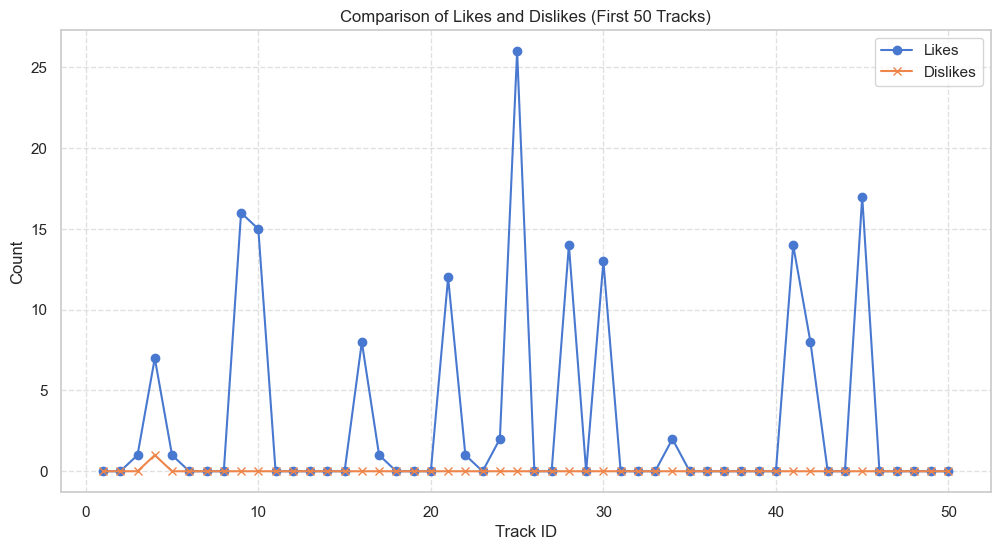

In [11]:
# Multi-line Chart: Likes vs Dislikes (First 50 Tracks)
sample_tracks = df_tracks.head(50)
plt.figure(figsize=(12, 6))
plt.plot(sample_tracks['track_id'], sample_tracks['total_likes'], label='Likes', marker='o')
plt.plot(sample_tracks['track_id'], sample_tracks['total_dislikes'], label='Dislikes', marker='x')

plt.title('Comparison of Likes and Dislikes (First 50 Tracks)')
plt.xlabel('Track ID')
plt.ylabel('Count')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

---
### 👤 2.2 Grouped & Stacked Bar Charts: Top Users & Artists Engagement
Next, we want to see who drives the community! A **Stacked Bar Chart** is perfect for aggregating the absolute volume of both positive and negative sentiments into one distinct bar per user/artist.

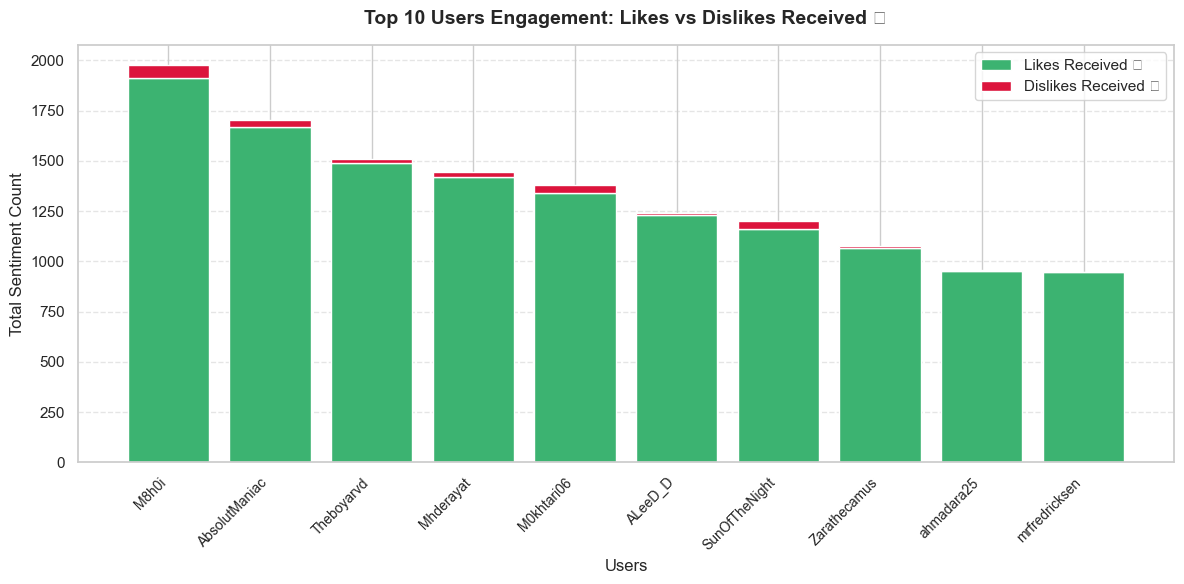

In [12]:
# Grouped/Stacked Bar: Top 10 Users Engagement
top_10_users = df_users.nlargest(10, 'num_likes_received')

plt.figure(figsize=(12, 6))

# Define X-axis labels
users_x = top_10_users['username'].fillna('Unknown')

# Create the stacked bar chart for Likes and Dislikes
p1 = plt.bar(users_x, top_10_users['num_likes_received'], label='Likes Received 💚', color='mediumseagreen')
p2 = plt.bar(users_x, top_10_users['num_dislikes_received'], bottom=top_10_users['num_likes_received'], label='Dislikes Received 💔', color='crimson')

plt.title('Top 10 Users Engagement: Likes vs Dislikes Received 🥇', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Total Sentiment Count', fontsize=12)
plt.xlabel('Users', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.legend(fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

_In the exact same way, let's observe which **Artists** reign at the top in this channel and how polarizing they are!_

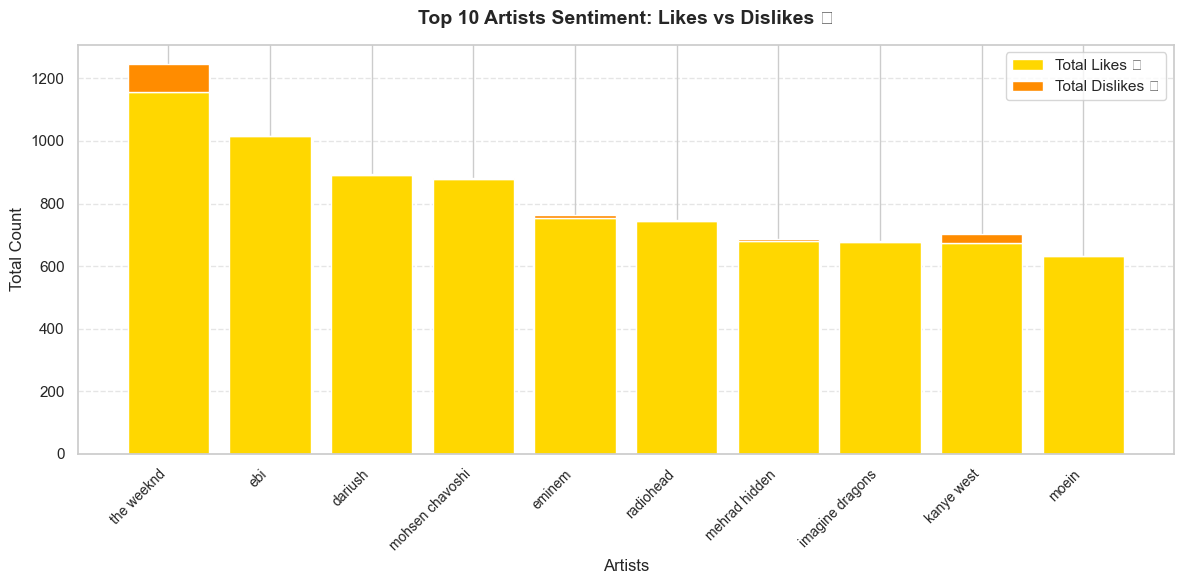

In [13]:
# Stacked Bar: Top 10 Artists Engagement (If columns exist for total artist likes, we map them otherwise calculate)
# Wait, look at df_artists! Typically it has total_likes and total_dislikes natively. Let's stack them!
top_10_artists = df_artists.nlargest(11, 'num_likes')
top_10_artists = top_10_artists[top_10_artists['artist_name'] != 'unknown artist']

plt.figure(figsize=(12, 6))
artists_x = top_10_artists['artist_name'].str[:20].fillna('Unknown')

plt.bar(artists_x, top_10_artists['num_likes'], label='Total Likes ⭐', color='gold')
plt.bar(artists_x, top_10_artists['num_dislikes'], bottom=top_10_artists['num_likes'], label='Total Dislikes 👎', color='darkorange')

plt.title('Top 10 Artists Sentiment: Likes vs Dislikes 🎤', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Total Count', fontsize=12)
plt.xlabel('Artists', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.legend(fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


In [14]:
import pandas as pd

# 1. Select the reciprocity metrics
# We use 'num_reactions' (Activity) and 'num_reactions_received' (Popularity)
reciprocity_data = df_users[['num_reactions', 'num_reactions_received']]

# 2. Calculate the Correlation Matrix
user_corr_matrix = reciprocity_data.corr()

# 3. Extract the specific correlation value
# Using .item() to avoid "Scalar" type-checking errors in IDEs
reciprocity_corr = user_corr_matrix.loc['num_reactions', 'num_reactions_received'].item()

print("User Engagement Matrix:")
print(user_corr_matrix)

print(f"\n--- Statistical Insight ---")
print(f"The Correlation between sending and receiving reactions is: {reciprocity_corr:.4f}")

if reciprocity_corr > 0.6:
    print("Insight: Strong Reciprocity. The most active givers are also the most popular receivers.")
elif reciprocity_corr > 0.3:
    print("Insight: Moderate Reciprocity. Activity helps popularity, but it's not the only factor.")
else:
    print("Insight: Low Reciprocity. Popularity in this group is likely driven by content quality rather than how much the user interacts with others.")

User Engagement Matrix:
                        num_reactions  num_reactions_received
num_reactions                1.000000                0.791871
num_reactions_received       0.791871                1.000000

--- Statistical Insight ---
The Correlation between sending and receiving reactions is: 0.7919
Insight: Strong Reciprocity. The most active givers are also the most popular receivers.


### COMMUNITY ENGAGEMENT REPORT: RECIPROCITY ANALYSIS

### Statistical Overview
- **Global Correlation**: 0.7919
- **Trend**: Strong Positive Correlation
- **Insight**: User activity is a primary driver of popularity.

### Visual Interpretation
1. **Density (Blue Hexagons)**: Most users are concentrated near the origin, showing a healthy baseline of casual engagement.
2. **The Reciprocity Line (Orange)**: The community follows the 1:1 line closely, indicating that status is largely earned through participation.
3. **Power Users (Red Dots)**: High-status users generally remain on or near the trend line, confirming that even "Superstars" remain active "Givers" in this ecosystem.

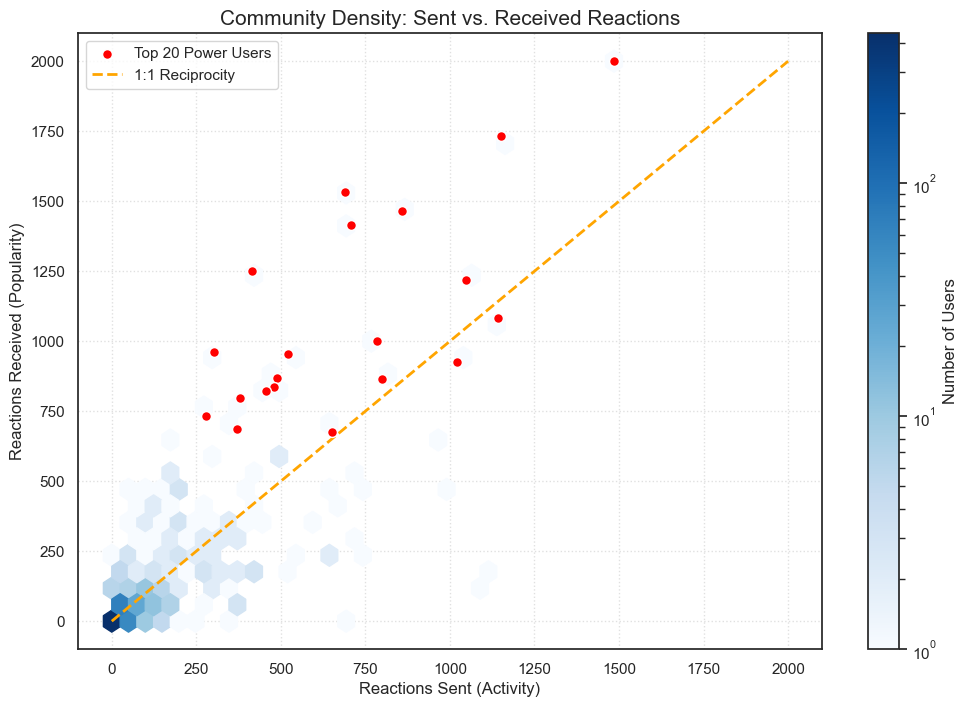

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as colors

# 1. Set the style
sns.set_theme(style="white")

# 2. Create the Hexbin plot
# This handles the overlapping points by showing density
plt.figure(figsize=(12, 8))
hb = plt.hexbin(
    df_users['num_reactions'], 
    df_users['num_reactions_received'], 
    gridsize=30, 
    cmap='Blues', 
    mincnt=1,
    norm=colors.LogNorm() # This fixes the "huge dot at zero" problem
)

# 3. Add a colorbar to show user density
cb = plt.colorbar(hb, label='Number of Users')

# 4. Highlight the Top 20 as distinct markers
top_20 = df_users.nlargest(20, 'num_reactions_received')
plt.scatter(
    top_20['num_reactions'], 
    top_20['num_reactions_received'], 
    color='red', 
    edgecolor='white', 
    s=50, 
    label='Top 20 Power Users',
    zorder=5
)

# 5. Add a 1:1 Reciprocity line for reference
max_val = max(df_users['num_reactions'].max(), df_users['num_reactions_received'].max())
plt.plot([0, max_val], [0, max_val], color='orange', linestyle='--', linewidth=2, label='1:1 Reciprocity')

# 6. Formatting
plt.title('Community Density: Sent vs. Received Reactions', fontsize=15)
plt.xlabel('Reactions Sent (Activity)', fontsize=12)
plt.ylabel('Reactions Received (Popularity)', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

In [34]:
import matplotlib.pyplot as plt
import pandas as pd

import plotly.graph_objects as go

# 1. Aggregate emoji counts from the original data
# We search the original dataframes (before encoding) for emoji occurrences
def get_emoji_counts(df, emoji_list):
    all_text = df.select_dtypes(include=['object']).stack().str.cat()
    return {emoji: all_text.count(emoji) for emoji in emoji_list}


# 1. Prepare Data (Reuse your existing grouping logic)
emoji_counts = get_emoji_counts(df_tracks_final, EMOJI_SCORES.keys())
total = sum(emoji_counts.values())

final_labels = []
final_values = []
others_count = 0
others_list = ""

for emoji, count in sorted(emoji_counts.items(), key=lambda x: x[1], reverse=True):
    if count == 0: continue
    if (count / total) < 0.01:
        others_count += count
        others_list += f" {emoji}"
    else:
        final_labels.append(emoji)
        final_values.append(count)

if others_count > 0:
    final_labels.append("others")
    final_values.append(others_count)

# 2. Create Interactive Plotly Figure
fig = go.Figure(data=[go.Pie(
    labels=final_labels, 
    values=final_values,
    hole=0, 
    textinfo='none',  # This hides the text on the pie slices
    hoverinfo='label+percent+value',
    marker=dict(line=dict(color='#000000', width=1))
)])

# 3. Update Layout for better visuals and interaction
fig.update_layout(
    title_text="Dominant Community Emojis",
    annotations=[dict(text='Hover to see Emojis', x=0.5, y=-0.1, font_size=12, showarrow=False)],
    # Increase the pull on hover
    hoverlabel=dict(bgcolor="white", font_size=16, font_family="Segoe UI Emoji")
)

# This enables the "pull" effect on hover in modern browsers
fig.update_traces(
    hoverinfo='label+percent+value', 
    textfont_size=14,
    marker=dict(line=dict(color='#FFFFFF', width=2))
)

fig.show()
fig.show(renderer="png")

ValueError: 
Image export using the "kaleido" engine requires the Kaleido package,
which can be installed using pip:

    $ pip install --upgrade kaleido


### 🌐 Interactive Scatter & Bubble Chart (Plotly)
Instead of flat unyielding plots, we have been requested by the assignment to include a **beautiful Interactive Graphic**.
Let's spin up the advanced Plotly engine to make our dimensional mappings zoomable and readable. We will visualize how extreme the reaction culture scales against absolute likes—making the size equivalent to the number of artists collaborating on that track.

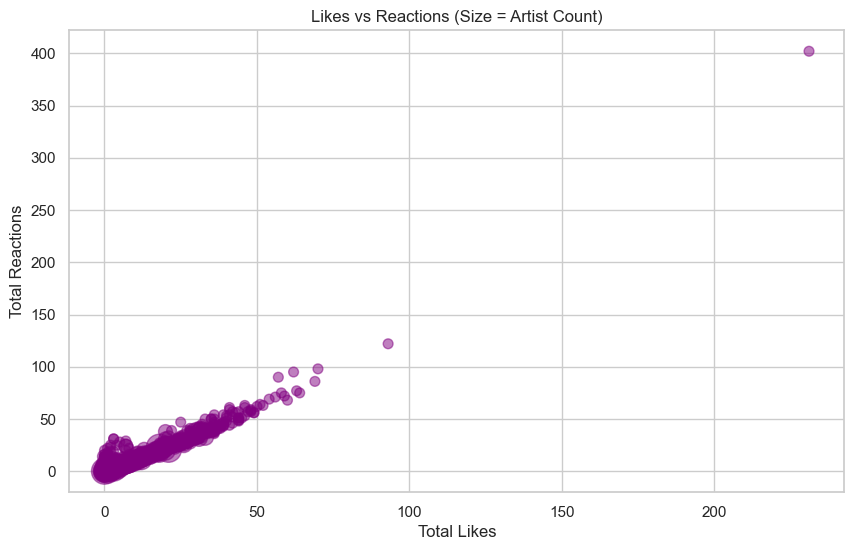

In [ ]:
# Bubble Chart
plt.figure(figsize=(10, 6))
plt.scatter(df_tracks['total_likes'], df_tracks['total_reactions'], 
            s=df_tracks['artist_count']*50, alpha=0.5, c='purple')

plt.title('Likes vs Reactions (Size = Artist Count)')
plt.xlabel('Total Likes')
plt.ylabel('Total Reactions')
plt.grid(True)
plt.show()

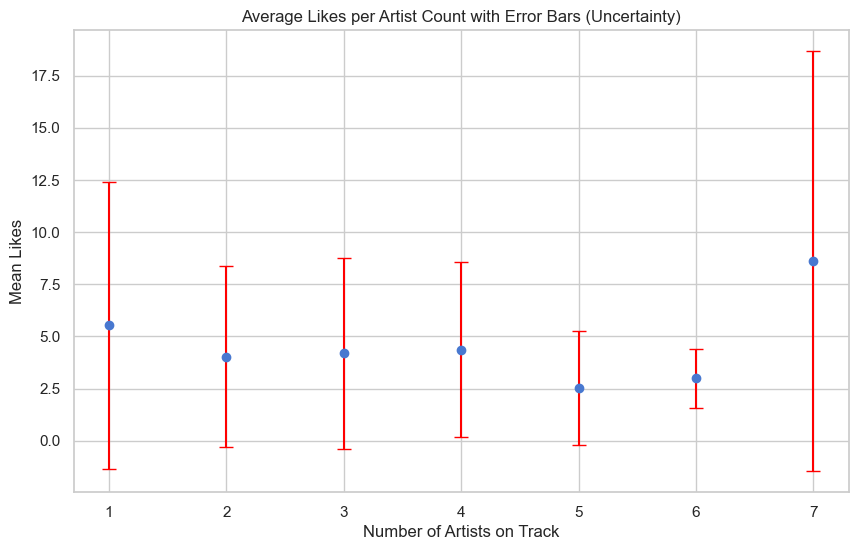

In [ ]:
import numpy as np

# Group by artist count and calculate mean/std
stats = df_tracks.groupby('artist_count')['total_likes'].agg(['mean', 'std']).reset_index()

plt.figure(figsize=(10, 6))
plt.errorbar(stats['artist_count'], stats['mean'], yerr=stats['std'], fmt='o', capsize=5, ecolor='red')
plt.title('Average Likes per Artist Count with Error Bars (Uncertainty)')
plt.xlabel('Number of Artists on Track')
plt.ylabel('Mean Likes')
plt.show()

---

#### 3️⃣ ⚙️ Feature Engineering
*   **Feature Invention:** Create insightful metrics via mathematical functions, combinations, ratios, and binning.
*   **Temporal Features:** Perform Date/Time transformations on the upload history.
*   **Aggregations:** Aggregate statistics and calculate counts (e.g., user activity metrics).
*   **Feature Selection:** Evaluate the relevance of features via Mutual Information.
*   **Dimensionality Reduction:** Utilize PCA to uncover the core variances in the dataset.
*   **Reflective Question:** Answer: *"When is feature engineering a nice-to-have option, and when is it a must-have?"*


---
#### 4️⃣ 🕸️ Web Scraping (Bonus Task)
*   **Bama.ir Target:** Write a simple script to scrape and extract data for 50 "Samand" cars manufactured after 1385.
*   **Target Fields:** Price, Mileage, Color, Production year, Transmission type (manual/auto), Description.
*   **Deliverables:** Maintain scraping code and export results directly to an Excel (`.xlsx`) file appropriately mapped in the repo.